### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 14</center>
---

### Overview

The objective of this exercise is to study image compression methods. In principal, it can be distinguished between lossless and lossy compression. Furthermore, it can be distinguished between coding redundancy, interpixel redundancy, and psychovisual redundancy. This task sheet focuses on losless compression using interpixel redundancy.

To evaluate a compression, the compression ratio $C_R$ and the relative data redundancy $R_D$ can be used. If $n_1$ and $n_2$ are the numbers of information-carrying units (bits or bytes), they can be computed as follows:

$$C_R = \dfrac{n_1}{n_2}$$

$$R_D = 1-\dfrac{1}{C_R}$$

The following figure shows a simplified system structure which obtains a *losless* compression $f_c(x,y)$ for a given image $f(x,y)$, and the reconstruction of the original image:
<br />
<center><img src="images/simple-compression.png"  width="600px" /></center>
<br />

Note that the mapper transforms the input data into a (usually non-visual) format to reduce interpixel redundancies. When these information are transferred to a channel (harddisk, internet connection, etc.), it is common to add a quantizer and a symbol encoder for more efficient coding (e.g. variable length coding), which are then additional components of the (source) encoder / decoder.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot image in original size
def plot_img_orig(img):
    fig = plt.figure(figsize = (img.shape[1]/dpi, img.shape[0]/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255) # cmap parameter is ignored for RGB(A) data
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 14.1</span> Run-Length Encoding (RLE)

Run-length encoding (also referred to as run-length coding, RLC) is a simple method for lossless data compression. The method uses interpixel redundancies by representing each pixel *run* (a sequence with the same intensity) as a pair of the intensity and the number of pixels in the sequence (e.g., [<span style="color: blue;">1, 1, 1,</span> <span style="color: red;">2, 2, 2, 2, 2</span>] → [<span style="color: blue;">1, 3,</span> <span style="color: red;">2, 5</span>] ). Along with specific extensions, it is also used for facsimile (FAX) compression. If there are only short pixel runs, there is no compression or even extension.

In this exercise, the images can be flattend using <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html">`flatten` ↗ </a> from Numpy to obtain a 1D representation. The RLE representation can then be computed in a 1D manner. The Numpy function <a href="https://numpy.org/doc/stable/reference/generated/numpy.append.html">`append` ↗</a> can be used to append values to an existing array (empty arrays are already provided for convenience).

Implement / solve the following tasks:
    
1. Implement an 8 bit (`dtype=np.uint8`) based RLE encoder which works in a 1D manner as described above. 
2. Compute the compression ratio and relative data redundancy for the following test images: *stripes.png*, *stripes-vertical.png*, *lena-250x250.png*, *upb-logo.png*.
3. Implement the corresponding RLE decoder and test it by plotting the decoded images (<span style="color: RoyalBlue; font-weight: bold;">*</span>).

For the development of your functions, the test image *stripes.png* is particularly helpful, because it contains lines of constant intensities so that it is more easy to check for a correct RLE representation.

(<span style="color: RoyalBlue; font-weight: bold;">*</span>) The file (module) `secret_image.py` is already imported below and contains a secret image in a 1D RLE representation as described above. This image can be used to start with the implementation of the decoder (maybe somewhat easier than starting with the encoder).

In [2]:
# compute rle for given image
def encode_rle(img):
    # empty array where the pairs are appended consecutively
    res = np.array([])
    
    # create 1d version of input
    img_flat = img.copy().flatten()

    # iterate over flat image
    val = img_flat[0] # initial value
    npx = 1 # counter variable (number of pixels with same intensity)
    
    for i in range(1, img_flat.size):
        # check if current value is last value
        if img_flat[i] == val:
            npx += 1 # increase counter
            
        else: # new value found => save old ones and reinitialize
            res = np.append(res, [val, npx]) # append previous values to array
            npx = 1 # reset counter
            val = img_flat[i] #val takes the new value from flatten array
            
        # last pixel reached => save sequence
        if i == (img_flat.size-1):
            res = np.append(res, [val, npx])

    # return result (rle compressed image)
    return res.astype(dtype=np.uint8)

In [3]:
img = cv2.imread('images/stripes-vertical.png', 0)
img_flat = img.copy().flatten()
img_flat

array([240, 247, 218, ...,  66, 139,  54], dtype=uint8)

In [4]:
print(img_flat.size)
250*250

62500


62500

In [5]:
en_rle = encode_rle(img)
en_rle.shape# = 500, after encoding.

(125000,)

In [6]:
# compute image from given rle encoded representation (1D array) with known number of rows and cols.
# the number of rows and cols can also be stored as additional control data (not done here) .
def decode_rle(img_rle, rows, cols):
    # empty array where the pairs are appended consecutively.
    res = np.array([])

    # get number of pairs
    npairs = int(img_rle.size / 2) # result would be float, so typecasting is needed.
    
    # get pairs (to build flat image with pixel values and number of occurance).
    for iy in range(npairs):
        val = img_rle[2*iy] # value is always at the first position. [[54,_], [60,_], [24,_] ... ]
        npx = int(img_rle[2*iy+1]) # number of pixel with same intensity [[_,250], [_,250] ... ]

        # append val for npx times
        for jx in range(npx):
            res = np.append(res, val)
    #print(res.shape) 62500, flattend array as before.
    # reshape 1D array to 2D
    res = np.reshape(res, (rows, cols))

    # return result (decompressed image)
    return res.astype(dtype=np.uint8)

In [7]:
de_rle = decode_rle(en_rle, 250,250)
de_rle.shape

(250, 250)

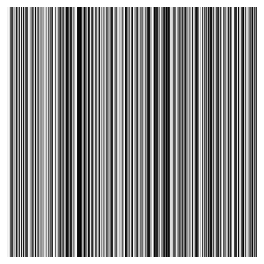

In [8]:
plot_img_orig(de_rle)

In [54]:
# compress, decompress and analyze using rle (img = path to image)
def compress_decrompress_analyze_rle(img):
    # read the image as a grayscale image (parameter 0)
    img_in = cv2.imread(img, 0)
    rows, cols = img_in.shape
    
    print("Input image (" + str(rows) + " x " + str(cols) + " px, Type: " + str(img_in.dtype) + "):");
    plot_img_orig(img_in)
    
    # compute rle encoded representation
    img_rle = encode_rle(img_in)
    #np.set_printoptions(threshold=np.inf)
    #print(img_rle)
    print("RLE Type: " + str(img_rle.dtype))

    # decode data
    img_decoded = decode_rle(img_rle, rows, cols)
    print("Decoded image:");
    plot_img_orig(img_decoded)
    #print(img_decoded)

    # print number of bytes
    print("Number of bytes input: " + str(img_in.nbytes))

    # print number of bytes
    print("Number of bytes compressed: " + str(img_rle.nbytes))

    # compute the compression ratio and relative data redundancy
    cr = img_in.nbytes / img_rle.nbytes
    rdr = 1-(1/cr)
    print("Compression ratio: " + str(cr))
    print("Relative data redundancy: " + str(rdr))

Input image (250 x 250 px, Type: uint8):


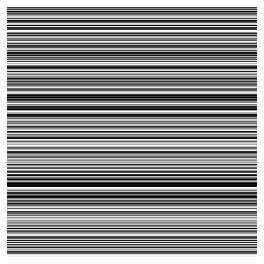

RLE Type: uint8
Decoded image:


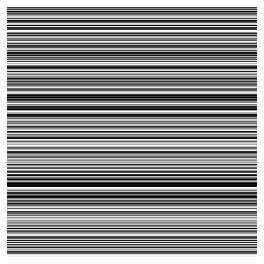

Number of bytes input: 62500
Number of bytes compressed: 500
Compression ratio: 125.0
Relative data redundancy: 0.992


In [55]:
# test of different images
compress_decrompress_analyze_rle('images/stripes.png')

Input image (250 x 250 px, Type: uint8):


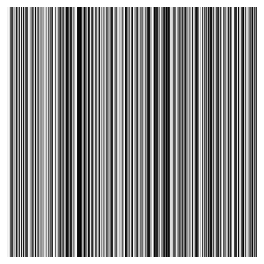

RLE Type: uint8
Decoded image:


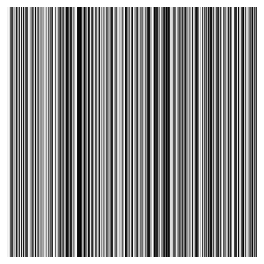

Number of bytes input: 62500
Number of bytes compressed: 125000
Compression ratio: 0.5
Relative data redundancy: -1.0
Input image (250 x 250 px, Type: uint8):


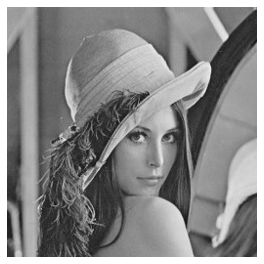

RLE Type: uint8
Decoded image:


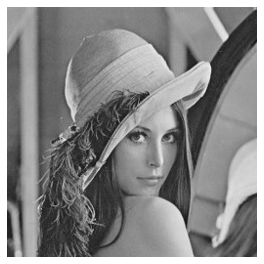

Number of bytes input: 62500
Number of bytes compressed: 113160
Compression ratio: 0.5523153057617533
Relative data redundancy: -0.8105600000000002
Input image (110 x 250 px, Type: uint8):


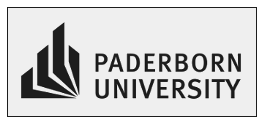

RLE Type: uint8
Decoded image:


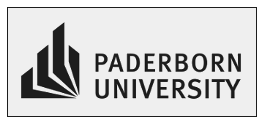

Number of bytes input: 27500
Number of bytes compressed: 9800
Compression ratio: 2.806122448979592
Relative data redundancy: 0.6436363636363637


In [64]:
compress_decrompress_analyze_rle('images/stripes-vertical.png')
compress_decrompress_analyze_rle('images/lena-250x250.png')
compress_decrompress_analyze_rle('images/upb-logo.png')

In [65]:
# secret image - can you decode and plot it?
import secret_image as si

print("\n" + "Secret image:") # \n is a new line
print("rows: " + str(si.rows))
print("cols: " + str(si.cols))
#np.set_printoptions(threshold=100)
print("RLE representation: " + str(si.img_rle))


Secret image:
rows: 250
cols: 250
RLE representation: [136 128  14 ...   5 136  88]


Note that all test images have less then 255 rows and columns. This is to avoid more then 255 consecutive pixels with the same intensity, because with 8 bit we can only store values from 0 to 255. This also the reason why some test images have a border (if the RLE is used for the 1D representation of the image, the consecutive pixels are counted across the rows). For larger numbers, we need more bits so that the compression ratio becomes worse. Most of these issues can be solved by more advanced implementations (e.g., analyzing the data in 2D, encoding each line individually etc.).

#### <span style="color: RoyalBlue; font-weight: bold;">Task 14.2</span> Bit-Plane Coding with Gray Code

The principal idea of bit-plane coding is to decompose an image into a series of binary images and then use specific binary compression methods. One drawback is that adjacent numbers (intensity values) can lead to very different bit planes (e.g., $127_{10} = 01111111_2$ and $128_{10} = 10000000_2$, which means that all bit planes are changed, although the numbers are so close together). This can lead to complex bit-plane representations of actually connected pixels. The encoding becomes more easy if adjacent numbers (intensity values) are only differing by one bit. This can be achieved by using gray code.

For an 8 bit binary number $a_7 a_6 a_5 a_4 a_3 a_2 a_1 a_0$ ($a_0$ is the least significant bit), the corresponding gray code $g_7 g_6 g_5 g_4 g_3 g_2 g_1 g_0$ can be computed as follows ($\oplus$ means XOR):

$$g_i = a_i \oplus a_{i+1}$$
$$g_7 = a_7$$

Note that the result for $g_7$ corresponds to $g_7 = a_7 \oplus a_8$ with $a_8 = 0$. Based on the gray code, the corresponding binary representation can be computed using successive XOR operations:

$$a_7 = g_7$$
$$a_6 = g_7 \oplus g_6$$
$$a_5 = g_7 \oplus g_6 \oplus g_5$$
$$\cdots$$
$$a_0 = g_7 \oplus g_6 \oplus g_5 \oplus \cdots \oplus g_0$$

Implement / solve the following tasks:
    
1. Compute and plot the bit-plane which corresponds to $a_5$ for the image *lena-250x250.png*.
2. Compute and plot the gray code plane which corresponds to $g_5$.
3. Save both planes as PNG images.
4. Compute the compression ratio and relative data redundancy between the files and compare the results. Functions to compute the file size are already provided for convenience.

Input image:


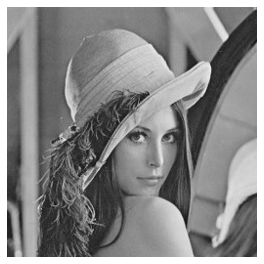

In [74]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/lena-250x250.png', 0)
print("Input image:")
plot_img_orig(img)

a_5:


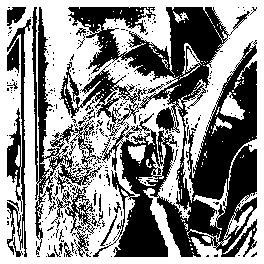

In [98]:
# compute and plot bit plane a_5 (also see task sheet 4)
img_ones = np.ones(shape=img.shape, dtype=np.uint8)
a_5 = cv2.bitwise_and(img >> 5, img_ones)

print("a_5:")
plot_img_orig(255*a_5)

g_5:


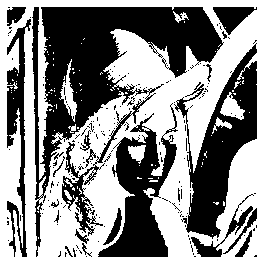

In [99]:
# compute and plot the gray code of this plane (we also need a_6 for this)
a_6 = cv2.bitwise_and(img >> 6, img_ones)
g_5 = cv2.bitwise_xor(a_5, a_6)

print("g_5:")
plot_img_orig(255*g_5)

g_0:


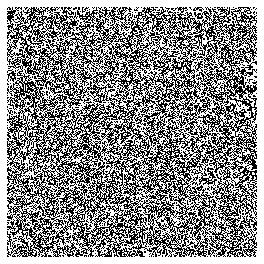

In [97]:
a_1 = cv2.bitwise_and(img >> 1, img_ones)
a_0 = cv2.bitwise_and(img >> 0, img_ones)
g_0 = cv2.bitwise_xor(a_0, a_1)
print("g_0:")
plot_img_orig(255*g_0)

In [77]:
# save planes as png images
cv2.imwrite('output/a_5.png', 255*a_5) #binary image, 255 or 0 pixel values
cv2.imwrite('output/g_5.png', 255*g_5)

True

In [82]:
# compare the file sizes
import os
a_5_size = os.stat('output/a_5.png')
g_5_size = os.stat('output/g_5.png')

print("a_5.png: ", a_5_size.st_size, "bytes")
print("g_5.png: ", g_5_size.st_size, "bytes")

a_5.png:  9531 bytes
g_5.png:  7050 bytes


In [83]:
# compute the compression ratio and relative data redundancy
cr = a_5_size.st_size / g_5_size.st_size
rdr = 1-(1/cr)
print("Compression ratio: " + str(cr))
print("Relative data redundancy: " + str(rdr))

Compression ratio: 1.3519148936170213
Relative data redundancy: 0.260308467107334


The gray coded bit plane has a much lower complexity than the normal bit plane. As a result, the lossless PNG compression leads to a smaller file size (approx. 75 % of the original size).

#### <span style="color: RoyalBlue; font-weight: bold;">Task 14.3</span> Lempel-Ziv-Welch (LZW) Coding 

LZW coding is a popular losless compression method to remove coding redundancy *and* interpixel redundancy. For this purpose, the method assigns fixed-length code words to variable length sequences of source symbols. An advantage of this method is that it requires no a priori knowledge of the probability of occurrence of the symbols to be encoded, because it encodes the data while processing it.

The idea of the method is simple yet powerful: reoccurring sequences are systematically added to a dictionary so that specific sequences are stored by one entry. It is more efficient to store the position in the dictionary instead of the complete sequence. This leads to a compression. Of course, the dictionary has to be known to decode the compressed representation.

The following figure illustrates the method:
<br />
<center><img src="images/lzw.png"  width="400px" /></center>
<br />

Implement / solve the following tasks:
    
1. Write a function to reproduce the example from the table and print the dictionary and the code.
2. Based on this function, compute the dictionary and the code for the image *upb-logo.png* using 1D string representations (e.g., "42|255|12").
3. Compare the number of pixels of the input image and the size of the code (number of entries).
4. Compute the corresponding compression ratio and relative data redundancy and compare the results (number of pixels vs. size of the code).

In [9]:
# initial dictionary
dict = np.array(['a', 'b', 'c'])

# create input 
input = np.array(['a', 'b', 'a', 'b', 'c'])

# empty code output
code = np.array([], dtype=np.uint8)

# check if passed seq(uence) is in dictionary and return index
def in_dict(seq):
    if seq in dict:
        return np.where(dict == seq)[0] # take 1st element [0] because result is tuple
    else:
        return 0

# process input
last_seq = input[0]
for i in range(1, input.size):
    seq = last_seq + input[i]
    
    # check if this sequence is in the dictionary
    if in_dict(seq) == False:
        dict = np.append(dict, seq)
        code = np.append(code, in_dict(last_seq))
        last_seq = input[i]
    else: # sequence has been found
        last_seq = seq
        
    # just print last element
    if i == input.size-1:
        code = np.append(code, in_dict(input[i]))
        
print("dict = " + str(dict))
print("code = " + str(code))

dict = ['a' 'b' 'c' 'ab' 'ba' 'abc']
code = [0 1 3 2]


In [103]:
# initial dictionary (arange can not be used to get a string representation)
dict = np.array([], dtype=object)
for i in range(256):
    dict = np.append(dict, str(i))

# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/upb-logo.png', 0)
img_flat = img.copy().flatten()
    
# empty code output
code = np.array([], dtype=object)

# process input
last_seq = img_flat[0]
for i in range(1, img_flat.size):
    seq = str(last_seq) + "|" + str(img_flat[i])
    
    # check if this sequence is in the dictionary
    if in_dict(seq) == False:
        dict = np.append(dict, seq)
        code = np.append(code, in_dict(last_seq))
        last_seq = str(img_flat[i])
    else: # sequence has been found
        last_seq = seq
        
    # just print last element
    if i == input.size-1:
        code = np.append(code, in_dict(input[i]))

# compare the number of pixels and the size of the dictionary.
#np.set_printoptions(threshold=np.inf)
print("dict = " + str(dict))
print("code = " + str(code))

dict = ['0' '1' '2' ...
 '29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29'
 '29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29'
 '29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29|29']
code = [0 256 0 ... 4071 4072 4073]


In [104]:
# comparison of pixels and code entries
print(img_flat.size)
print(dict.size)

27500
4075


In [105]:
# compute the compression ratio and relative data redundancy
cr = img_flat.size / code.size
rdr = 1-(1/cr)
print("Compression ratio: " + str(cr))
print("Relative data redundancy: " + str(rdr))

Compression ratio: 7.198952879581152
Relative data redundancy: 0.8610909090909091
